In [1]:
from langgraph.graph import StateGraph, START, END
# from langchain_openai import ChatOpenAI
from langchain_google_genai import ChatGoogleGenerativeAI
from typing import TypedDict
from dotenv import load_dotenv

In [2]:
load_dotenv()

# model = ChatOpenAI()
model = ChatGoogleGenerativeAI(model='gemini-2.5-flash')

In [3]:
class BlogState(TypedDict):

    title: str
    outline: str
    content: str

In [4]:
def create_outline(state: BlogState) -> BlogState:

    # fetch title
    title = state['title']

    # call llm gen outline
    prompt = f'Generate a detailed outline for a blog on the topic - {title}'
    outline = model.invoke(prompt).content

    # update state
    state['outline'] = outline

    return state

In [5]:
def create_blog(state: BlogState) -> BlogState:

    title = state['title']
    outline = state['outline']

    prompt = f'Write a detailed blog on the title - {title} using the follwing outline \n {outline}'

    content = model.invoke(prompt).content

    state['content'] = content

    return state

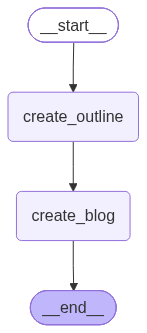

In [6]:
graph = StateGraph(BlogState)

# nodes
graph.add_node('create_outline', create_outline)
graph.add_node('create_blog', create_blog)

# edges
graph.add_edge(START, 'create_outline')
graph.add_edge('create_outline', 'create_blog')
graph.add_edge('create_blog', END)

workflow = graph.compile()
graph.compile()

In [7]:
intial_state = {'title': 'Rise of AI in India'}

final_state = workflow.invoke(intial_state)

print(final_state)

Direct use of automatic function calling (AFC) in Models.generate_content is not recommended. Instead, we recommend to use AFC in Chat.send_message. Similarly, direct use of AFC in Models.generate_content_stream is not recommended. Instead, we recommend to use AFC in Chat.send_message_stream.


{'title': 'Rise of AI in India', 'outline': 'Here\'s a detailed outline for a blog post on "The Rise of AI in India," designed to be comprehensive, engaging, and informative.\n\n---\n\n## Blog Title Options:\n\n*   The AI Ascent: Unpacking India\'s Rapid Rise in Artificial Intelligence\n*   India\'s AI Awakening: How the Nation is Shaping the Future of Tech\n*   From Bangalore to Bharat: The Transformative Journey of AI in India\n*   Beyond the Hype: Understanding India\'s Strategic Push for AI Leadership\n\n---\n\n## Blog Outline: The AI Ascent: Unpacking India\'s Rapid Rise in Artificial Intelligence\n\n**Target Audience:** Tech enthusiasts, industry professionals, policymakers, students, investors, and anyone interested in India\'s digital transformation.\n\n**Tone:** Informative, optimistic, slightly analytical, forward-looking.\n\n---\n\n### I. Introduction (Approx. 150-200 words)\n\n*   **A. Hook:** Start with a compelling statement about the global AI revolution and its profound

In [8]:
print(final_state['outline'])

Here's a detailed outline for a blog post on "The Rise of AI in India," designed to be comprehensive, engaging, and informative.

---

## Blog Title Options:

*   The AI Ascent: Unpacking India's Rapid Rise in Artificial Intelligence
*   India's AI Awakening: How the Nation is Shaping the Future of Tech
*   From Bangalore to Bharat: The Transformative Journey of AI in India
*   Beyond the Hype: Understanding India's Strategic Push for AI Leadership

---

## Blog Outline: The AI Ascent: Unpacking India's Rapid Rise in Artificial Intelligence

**Target Audience:** Tech enthusiasts, industry professionals, policymakers, students, investors, and anyone interested in India's digital transformation.

**Tone:** Informative, optimistic, slightly analytical, forward-looking.

---

### I. Introduction (Approx. 150-200 words)

*   **A. Hook:** Start with a compelling statement about the global AI revolution and its profound impact.
    *   *Example:* "Artificial Intelligence isn't just a buzzword

In [9]:
print(final_state['content'])

## The AI Ascent: Unpacking India's Rapid Rise in Artificial Intelligence

Artificial Intelligence isn't just a buzzword; it's the defining technology of our era, reshaping industries, economies, and societies worldwide. From autonomous vehicles to personalized medicine, AI's profound impact is undeniable. While global tech giants often lead the charge, a new powerhouse is rapidly emerging on the AI landscape, poised to become a significant global player: India.

India is rapidly transforming into a global AI hub, driven by a unique confluence of a vast talent pool, robust digital infrastructure, proactive government support, and a burgeoning startup ecosystem. This strategic positioning allows India to leverage AI not only for unprecedented economic growth but also for addressing critical societal challenges and fostering inclusive development. Throughout this blog, we will delve into the foundational strengths propelling India's AI journey, explore the transformative applications acr